In [394]:
import pandas as pd
import numpy as np

In [395]:
df = pd.read_csv('/content/drive/MyDrive/titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [396]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [397]:
df = df.drop('Cabin', axis=1, errors='ignore')

In [398]:
df['Age'] = df['Age'].fillna(df['Age'].mean()) #평균값
df['Age']

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [399]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [400]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
print(df['Sex'].unique())

[0 1]


In [401]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

print(df['Embarked'].unique())

[2 0 1]


In [402]:
X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket','Fare','Embarked'], axis=1)
y = df['Survived']
X

,Pclass,Sex,Age,SibSp,Parch
0,3,0,22.000000,1,0
1,1,1,38.000000,1,0
2,3,1,26.000000,0,0
3,1,1,35.000000,1,0
4,3,0,35.000000,0,0
...,...,...,...,...,...
886,2,0,27.000000,0,0
887,1,1,19.000000,0,0
888,3,1,29.699118,1,2
889,1,0,26.000000,0,0


In [403]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [404]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

model = LogisticRegression(random_state=0, max_iter=5000)
model.fit(X_train, y_train)

pred_lr = model.predict(X_test)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr))
print (confusion_matrix(y_test, pred_lr))


--- Logistic Regression Classifier ---
0.7982062780269058
[[116  23]
 [ 22  62]]


In [405]:
from sklearn.tree import DecisionTreeClassifier

clf_DT = DecisionTreeClassifier(random_state=0)
clf_DT.fit(X_train, y_train)

pred_DT = clf_DT.predict(X_test)

print ("\n--- DecisionTreeClassifier ---")
print (accuracy_score(y_test, pred_DT))
print (confusion_matrix(y_test, pred_DT))


--- DecisionTreeClassifier ---
0.7847533632286996
[[120  19]
 [ 29  55]]


In [406]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train)

pred_RF = model.predict(X_test)

print ("\n--- RandomForestClassifier ---")
print (accuracy_score(y_test, pred_RF))
print (confusion_matrix(y_test, pred_RF))


--- RandomForestClassifier ---
0.7937219730941704
[[115  24]
 [ 22  62]]


In [407]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

pred_knn = model.predict(X_test)

print ("\n--- KNeighborsClassifier ---")
print (accuracy_score(y_test, pred_knn))
print (confusion_matrix(y_test, pred_knn))



--- KNeighborsClassifier ---
0.7623318385650224
[[119  20]
 [ 33  51]]


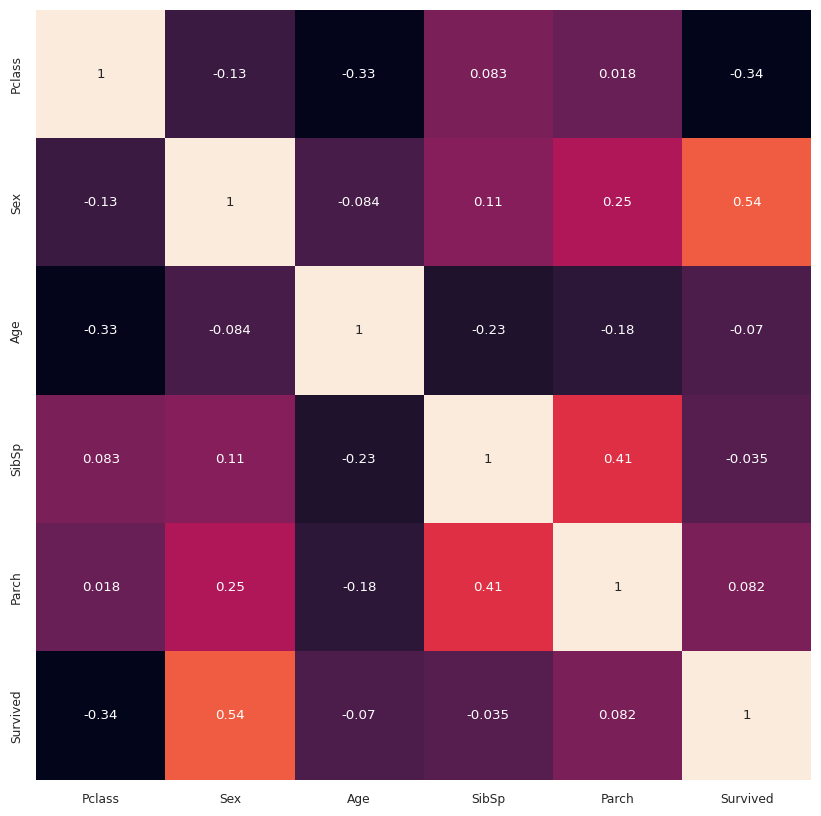

In [408]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns


corr_df = pd.concat([X, y], axis=1)
df_corr = corr_df.corr()


plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()


In [409]:
X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)
y = df['Survived']
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.000000,1,0,7.2500,2
1,1,1,38.000000,1,0,71.2833,0
2,3,1,26.000000,0,0,7.9250,2
3,1,1,35.000000,1,0,53.1000,2
4,3,0,35.000000,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,2,0,27.000000,0,0,13.0000,2
887,1,1,19.000000,0,0,30.0000,2
888,3,1,29.699118,1,2,23.4500,2
889,1,0,26.000000,0,0,30.0000,0


In [410]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [411]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

model= LogisticRegression(random_state=0, max_iter=5000)
model.fit(X_train, y_train)

pred_lr = model.predict(X_test)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr))
print (confusion_matrix(y_test, pred_lr))


--- Logistic Regression Classifier ---
0.7937219730941704
[[116  23]
 [ 23  61]]


In [412]:
from sklearn.tree import DecisionTreeClassifier

model= DecisionTreeClassifier(random_state=0)
model.fit(X_train, y_train)

pred_dt = model.predict(X_test)

print ("\n--- DecisionTreeClassifier ---")
print (accuracy_score(y_test, pred_dt))
print (confusion_matrix(y_test, pred_dt))



--- DecisionTreeClassifier ---
0.757847533632287
[[112  27]
 [ 27  57]]


In [413]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train)

pred_rt = model.predict(X_test)

print ("\n--- RandomForestClassifier ---")
print (accuracy_score(y_test, pred_rt))
print (confusion_matrix(y_test, pred_rt))



--- RandomForestClassifier ---
0.8251121076233184
[[123  16]
 [ 23  61]]


In [414]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

pred_knn = model.predict(X_test)

print ("\n--- KNeighborsClassifier ---")
print (accuracy_score(y_test, pred_knn))
print (confusion_matrix(y_test, pred_knn))


--- KNeighborsClassifier ---
0.7309417040358744
[[112  27]
 [ 33  51]]


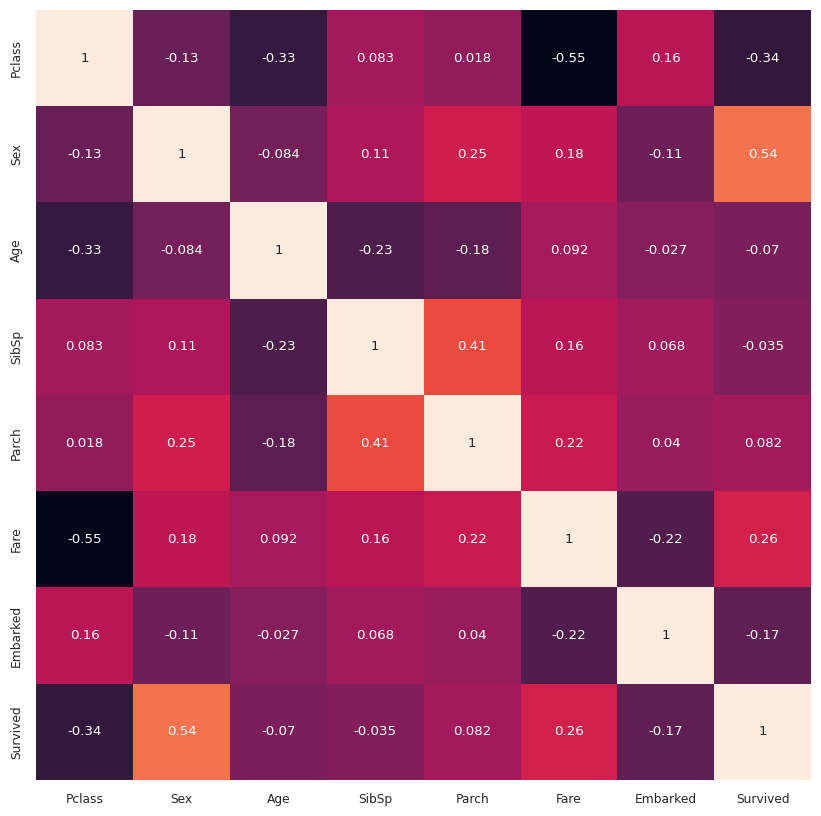

In [415]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns


corr_df = pd.concat([X, y], axis=1)
df_corr = corr_df.corr()


plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()